<a href="https://colab.research.google.com/github/Aidisonn/odoo-test/blob/main/adhd_model_training_unfinish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
AdhdDF = pd.read_csv('/content/sample_data/ADHD.csv')

In [3]:
print("Shape:", AdhdDF.shape)
print("\n--- All columns and their data types ---")
print(AdhdDF.dtypes)

Shape: (506, 115)

--- All columns and their data types ---
age                                                                                                                                int64
sex                                                                                                                               object
specify                                                                                                                           object
home_language                                                                                                                     object
have_you_ever_experienced_any_mental_health_difficulties_or_symptoms_before_starting_university_e_g_in_primary_or_high_school     object
                                                                                                                                  ...   
Unnamed: 110                                                                                                          

In [4]:
AdhdDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Columns: 115 entries, age to Unnamed: 114
dtypes: float64(16), int64(83), object(16)
memory usage: 454.7+ KB


In [5]:
AdhdDF.describe()

,age,bdi1_item_1,bdi1_item_2,bdi1_item_3,bdi1_item_4,bdi1_item_5,bdi1_item_6,bdi1_item_7,bdi1_item_8,bdi1_item_9,...,bai1_item_20,bai1_item_21,bai1_total,asrs1_total.y,aas_change,Unnamed: 110,Unnamed: 111,Unnamed: 112,Unnamed: 113,Unnamed: 114
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,...,506.000000,506.000000,506.000000,505.000000,176.000000,0.0,0.0,0.0,0.0,0.0
mean,18.428854,0.517787,0.478261,0.452569,0.849802,0.719368,0.454545,0.474308,0.992095,0.349802,...,0.559289,0.790514,21.209486,21.360396,-0.019397,NaN,NaN,NaN,NaN,NaN
std,0.720202,0.803877,0.752897,0.775059,0.865837,0.837429,0.884917,0.778633,0.927008,0.627876,...,0.877351,1.024255,12.758829,12.773237,2.260037,NaN,NaN,NaN,NaN,NaN
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-6.080996,NaN,NaN,NaN,NaN,NaN
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,11.000000,11.000000,-1.604738,NaN,NaN,NaN,NaN,NaN
50%,18.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,20.000000,20.000000,0.100503,NaN,NaN,NaN,NaN,NaN
75%,19.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,...,1.000000,1.000000,30.000000,30.000000,1.805744,NaN,NaN,NaN,NaN,NaN
max,22.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,62.000000,62.000000,5.003071,NaN,NaN,NaN,NaN,NaN


In [6]:
print("\n--- Missing values per column ---")
missing = AdhdDF.isnull().sum()
print(missing[missing > 0])


--- Missing values per column ---
specify                                                                                                             495
if_yes_please_list_these_difficulties_and_or_symptoms                                                                81
if_you_have_ever_experienced_difficulties_and_or_symptoms_of_a_mental_illness_how_old_were_you_when_this_started     77
if_you_have_been_diagnosed_formally_or_informally_please_list_the_diagnosis_diagnoses                               129
if_you_have_been_diagnosed_with_a_mental_illness_at_what_age_was_this                                               150
aas1_item_1                                                                                                           2
aas1_item_2                                                                                                           1
aas1_item_3                                                                                                           1
aas1_

In [7]:
print("\n--- Unique value counts (to spot Yes/No, free text, IDs) ---")
for col in AdhdDF.columns:
    n_unique = AdhdDF[col].nunique()
    sample = AdhdDF[col].dropna().unique()[:4]
    print(f"{col:<80} | unique={n_unique} | sample={sample}")


--- Unique value counts (to spot Yes/No, free text, IDs) ---
age                                                                              | unique=5 | sample=[22 21 19 20]
sex                                                                              | unique=3 | sample=['female' 'male' 'other']
specify                                                                          | unique=4 | sample=['gender_fluid' 'agender' 'non-binary' 'transgender_female']
home_language                                                                    | unique=24 | sample=['xitsonga' 'english' 'isizulu' 'afrikaans/english']
have_you_ever_experienced_any_mental_health_difficulties_or_symptoms_before_starting_university_e_g_in_primary_or_high_school | unique=2 | sample=['no' 'yes']
if_yes_please_list_these_difficulties_and_or_symptoms                            | unique=292 | sample=['na' 'none' 'mental breakdowns.  anxiety.  panic attacks'
 'depression and anxiety, as well as adhd']
if_you_have_ev

In [8]:
!pip install vaderSentiment imbalanced-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.1 MB/s eta 0:00:00


In [9]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [10]:
# ── STEP 1: Drop clearly useless columns ──────────────────────────────
drop_cols = [
    # Zero variance
    'nbt_completed',
    # Age — no variance among first-years
    'age',
    # Year — not relevant to ADHD symptoms
    'nbt_year',
    # Nearly all missing
    'specify',           # 495/506 missing
    'aas_change',        # 330/506 missing
    'nbt_did_math',      # 216/506 missing
    # Too messy to use
    'if_you_have_ever_experienced_difficulties_and_or_symptoms_of_a_mental_illness_how_old_were_you_when_this_started',
    'if_you_have_been_diagnosed_with_a_mental_illness_at_what_age_was_this',
    'home_language',     # 24 fragmented categories, not ADHD-related
    # Duplicate / leakage
    'asrs1_total.y',
    # Entirely empty
    'Unnamed: 110', 'Unnamed: 111', 'Unnamed: 112',
    'Unnamed: 113', 'Unnamed: 114',
]
AdhdDF = AdhdDF.drop(columns=drop_cols, errors='ignore')
print(f"After dropping useless columns: {AdhdDF.shape}")

After dropping useless columns: (506, 100)


In [11]:
df = AdhdDF.copy()

print(f"Original shape: {AdhdDF.shape}")
print(f"Working copy shape: {df.shape}")

Original shape: (506, 100)
Working copy shape: (506, 100)


In [12]:
# ── STEP 2: Sentiment analysis on free-text columns ───────────────────
analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    if pd.isna(text) or str(text).strip() in ['', 'na', 'none', 'NA', 'None']:
        return 0.0
    return analyzer.polarity_scores(str(text))['compound']  # -1 to +1

free_text_cols = {
    'if_yes_please_list_these_difficulties_and_or_symptoms':
        'sentiment_mental_health_difficulties',
    'if_you_have_been_diagnosed_formally_or_informally_please_list_the_diagnosis_diagnoses':
        'sentiment_diagnosis_list',
}

for original_col, new_col in free_text_cols.items():
    if original_col in df.columns:
        df[new_col] = df[original_col].apply(vader_score)
        df = df.drop(columns=[original_col])
        print(f"Created: {new_col}")

print(f"After sentiment encoding: {df.shape}")

Created: sentiment_mental_health_difficulties
Created: sentiment_diagnosis_list
After sentiment encoding: (506, 100)


In [13]:
# ── STEP 3: Encode Yes/No and categorical columns ─────────────────────

# sex: female=0, male=1, other=2
df['sex'] = df['sex'].str.lower().map({'female': 0, 'male': 1, 'other': 2})

# Simple yes/no columns (not applicable treated as no = 0)
yes_no_map = {'yes': 1, 'no': 0, 'not applicable': 0}

yes_no_cols = [
    'have_you_ever_experienced_any_mental_health_difficulties_or_symptoms_before_starting_university_e_g_in_primary_or_high_school',
    'have_you_ever_used_prescribed_psychiatric_medication_for_a_mental_illness_or_symptoms_of_one',
    'are_you_currently_using_prescribed_psychiatric_medication_for_a_mental_illness_or_symptoms_of_one',
    'have_you_ever_been_to_therapy_or_counselling_for_a_mental_illness_or_symptoms_of_one',
    'are_you_currently_in_therapy_or_counselling_for_a_mental_illness_or_symptoms_of_one',
]
for col in yes_no_cols:
    if col in df.columns:
        df[col] = df[col].str.lower().map(yes_no_map)

# Diagnosis column: 3 levels
diag_col = 'have_you_ever_been_diagnosed_with_a_mental_illness'
if diag_col in df.columns:
    df[diag_col] = df[diag_col].str.lower().map({
        'no': 0,
        'not formally diagnosed': 1,
        'yes, formally diagnosed by a doctor or mental health professional': 2
    })

# Diagnosis timing
timing_col = 'was_this_diagnosis_made_before_or_after_you_left_high_school'
if timing_col in df.columns:
    df[timing_col] = df[timing_col].str.lower().map({
        'not applicable': 0,
        'before': 1,
        'after': 2
    })

# nbt_did_math was dropped above; if still present:
if 'nbt_did_math' in df.columns:
    df['nbt_did_math'] = df['nbt_did_math'].str.lower().map({'yes': 1, 'no': 0})

print(f"After encoding categoricals: {df.shape}")

After encoding categoricals: (506, 100)


In [14]:
# ── VERIFY STEP 3 ENCODING ────────────────────────────────────────────

encoded_cols = [
    'sex',
    'have_you_ever_experienced_any_mental_health_difficulties_or_symptoms_before_starting_university_e_g_in_primary_or_high_school',
    'have_you_ever_used_prescribed_psychiatric_medication_for_a_mental_illness_or_symptoms_of_one',
    'are_you_currently_using_prescribed_psychiatric_medication_for_a_mental_illness_or_symptoms_of_one',
    'have_you_ever_been_to_therapy_or_counselling_for_a_mental_illness_or_symptoms_of_one',
    'are_you_currently_in_therapy_or_counselling_for_a_mental_illness_or_symptoms_of_one',
    'have_you_ever_been_diagnosed_with_a_mental_illness',
    'was_this_diagnosis_made_before_or_after_you_left_high_school',
]

print("=" * 60)
print(f"{'COLUMN':<55} | {'UNIQUE VALUES':<20} | {'NaN COUNT'}")
print("=" * 60)

for col in encoded_cols:
    if col in df.columns:
        unique_vals = sorted(df[col].dropna().unique().tolist())
        nan_count   = df[col].isnull().sum()
        # Shorten long column names for display
        short_name  = col[:52] + '...' if len(col) > 52 else col
        print(f"{short_name:<55} | {str(unique_vals):<20} | {nan_count}")

print("=" * 60)
print(f"\nTotal NaN across all encoded columns: "
      f"{df[encoded_cols].isnull().sum().sum()}")

COLUMN                                                  | UNIQUE VALUES        | NaN COUNT
sex                                                     | [0, 1, 2]            | 0
have_you_ever_experienced_any_mental_health_difficul... | [0, 1]               | 0
have_you_ever_used_prescribed_psychiatric_medication... | [0, 1]               | 0
are_you_currently_using_prescribed_psychiatric_medic... | [0, 1]               | 0
have_you_ever_been_to_therapy_or_counselling_for_a_m... | [0, 1]               | 0
are_you_currently_in_therapy_or_counselling_for_a_me... | [0, 1]               | 0
have_you_ever_been_diagnosed_with_a_mental_illness      | [0, 1, 2]            | 0
was_this_diagnosis_made_before_or_after_you_left_hig... | [0, 1, 2]            | 0

Total NaN across all encoded columns: 0


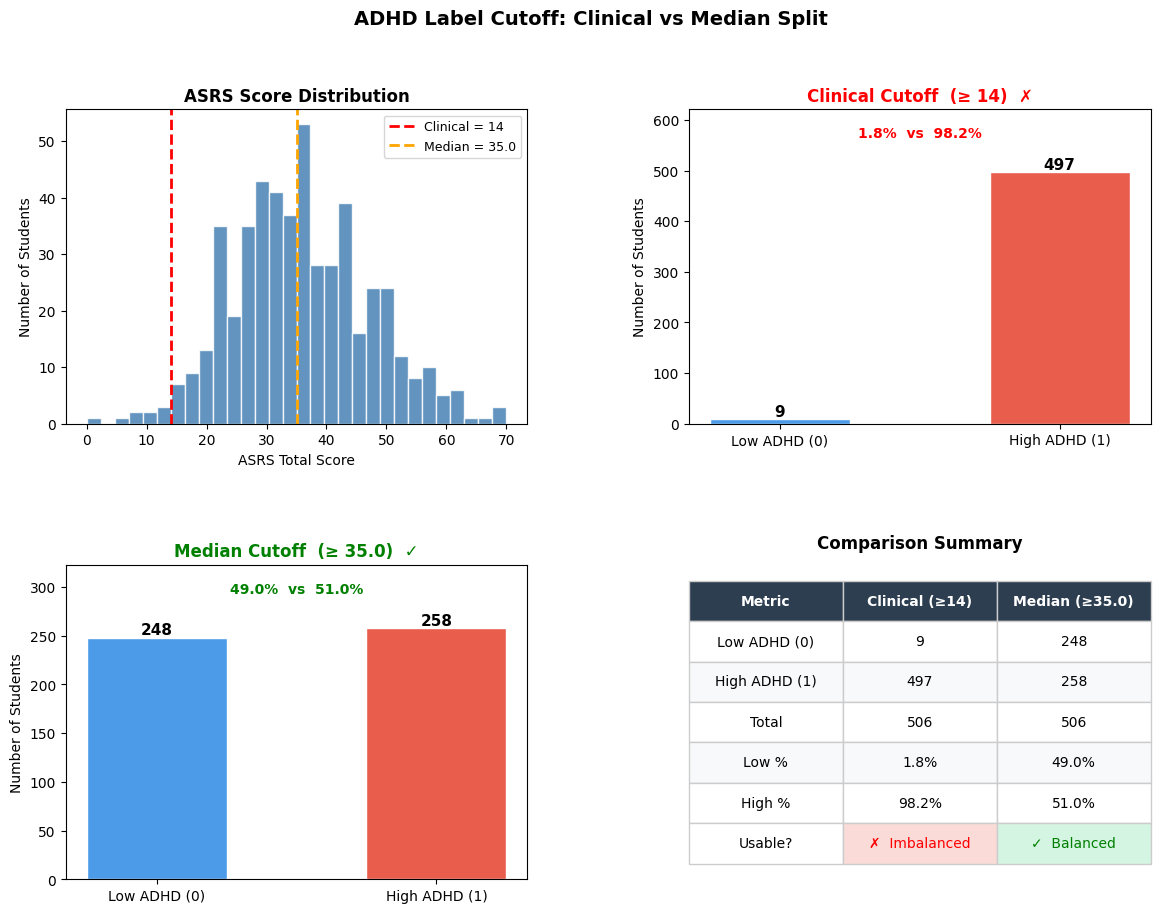


Clinical cutoff (14): 9 Low vs 497 High
Median  cutoff (35.0): 248 Low vs 258 High

✓ adhd_label created using median cutoff = 35.0
✓ Label distribution:
adhd_label
1    258
0    248
Name: count, dtype: int64
✓ adhd_label exists in df: True
✓ Shape after dropping ASRS cols: (506, 82)


In [15]:
# ── STEP 4: Create ADHD label + comparison chart ──────────────────────
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

asrs_col        = 'asrs1_total.x'
clinical_cutoff = 14
median_cutoff   = df[asrs_col].median()

clinical_labels = (df[asrs_col] >= clinical_cutoff).astype(int)
median_labels   = (df[asrs_col] >= median_cutoff).astype(int)

clinical_counts = clinical_labels.value_counts().sort_index()
median_counts   = median_labels.value_counts().sort_index()

pct1 = clinical_counts.values / clinical_counts.values.sum() * 100
pct2 = median_counts.values   / median_counts.values.sum()   * 100

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df[asrs_col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(clinical_cutoff, color='red',    linestyle='--', linewidth=2,
            label=f'Clinical = {clinical_cutoff}')
ax1.axvline(median_cutoff,   color='orange', linestyle='--', linewidth=2,
            label=f'Median = {median_cutoff}')
ax1.set_title('ASRS Score Distribution', fontweight='bold')
ax1.set_xlabel('ASRS Total Score')
ax1.set_ylabel('Number of Students')
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
bars1 = ax2.bar(['Low ADHD (0)', 'High ADHD (1)'],
                clinical_counts.values,
                color=['#4C9BE8', '#E85D4C'], edgecolor='white', width=0.5)
ax2.set_title(f'Clinical Cutoff  (≥ {clinical_cutoff})  ✗', fontweight='bold', color='red')
ax2.set_ylabel('Number of Students')
ax2.set_ylim(0, max(clinical_counts.values) * 1.25)
for bar, val in zip(bars1, clinical_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 6,
             str(val), ha='center', fontsize=11, fontweight='bold')
ax2.text(0.5, 0.91, f'{pct1[0]:.1f}%  vs  {pct1[1]:.1f}%',
         transform=ax2.transAxes, ha='center', fontsize=10,
         color='red', fontweight='bold')

ax3 = fig.add_subplot(gs[1, 0])
bars2 = ax3.bar(['Low ADHD (0)', 'High ADHD (1)'],
                median_counts.values,
                color=['#4C9BE8', '#E85D4C'], edgecolor='white', width=0.5)
ax3.set_title(f'Median Cutoff  (≥ {median_cutoff})  ✓', fontweight='bold', color='green')
ax3.set_ylabel('Number of Students')
ax3.set_ylim(0, max(median_counts.values) * 1.25)
for bar, val in zip(bars2, median_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', fontsize=11, fontweight='bold')
ax3.text(0.5, 0.91, f'{pct2[0]:.1f}%  vs  {pct2[1]:.1f}%',
         transform=ax3.transAxes, ha='center', fontsize=10,
         color='green', fontweight='bold')

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
table_data = [
    ['Metric',        f'Clinical (≥{clinical_cutoff})',  f'Median (≥{median_cutoff})'],
    ['Low ADHD (0)',  str(clinical_counts.get(0, 0)),     str(median_counts.get(0, 0))],
    ['High ADHD (1)', str(clinical_counts.get(1, 0)),     str(median_counts.get(1, 0))],
    ['Total',         str(len(clinical_labels)),          str(len(median_labels))],
    ['Low %',         f"{pct1[0]:.1f}%",                 f"{pct2[0]:.1f}%"],
    ['High %',        f"{pct1[1]:.1f}%",                 f"{pct2[1]:.1f}%"],
    ['Usable?',       '✗  Imbalanced',                   '✓  Balanced'],
]
tbl = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center', bbox=[0, 0.05, 1, 0.9])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == 6:
        if col == 1:
            cell.set_facecolor('#FADBD8')
            cell.set_text_props(color='red')
        elif col == 2:
            cell.set_facecolor('#D5F5E3')
            cell.set_text_props(color='green')
    elif row % 2 == 0:
        cell.set_facecolor('#F8F9FA')
ax4.set_title('Comparison Summary', fontweight='bold', pad=12)
fig.suptitle('ADHD Label Cutoff: Clinical vs Median Split',
             fontsize=14, fontweight='bold')
plt.savefig('cutoff_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClinical cutoff ({clinical_cutoff}): {clinical_counts.get(0,0)} Low vs {clinical_counts.get(1,0)} High")
print(f"Median  cutoff ({median_cutoff}): {median_counts.get(0,0)} Low vs {median_counts.get(1,0)} High")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# THIS IS WHAT WAS MISSING — actually apply the label and drop ASRS cols
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df['adhd_label'] = (df[asrs_col] >= median_cutoff).astype(int)

asrs_items = [c for c in df.columns if 'asrs1_item' in c]
df = df.drop(columns=asrs_items + [asrs_col], errors='ignore')

# Confirm label was created
print(f"\n✓ adhd_label created using median cutoff = {median_cutoff}")
print(f"✓ Label distribution:\n{df['adhd_label'].value_counts()}")
print(f"✓ adhd_label exists in df: {'adhd_label' in df.columns}")
print(f"✓ Shape after dropping ASRS cols: {df.shape}")

In [16]:
# ── STEP 5: Drop remaining text columns + fill NaN ────────────────────

# Check what text columns still remain
remaining_obj = df.select_dtypes(include='object').columns.tolist()
print(f"Remaining text columns: {remaining_obj}")

# Drop them — everything should already be numeric from Step 3
df = df.drop(columns=remaining_obj, errors='ignore')

# Drop fully empty columns
df = df.dropna(axis=1, how='all')

# Fill NaN with column median
df = df.fillna(df.median(numeric_only=True))

# Final safety net
df = df.fillna(0)

# Confirm
print(f"Final shape:      {df.shape}")
print(f"NaN remaining:    {df.isnull().sum().sum()}")  # must be 0
print(f"Columns:          {df.columns.tolist()}")

Remaining text columns: []
Final shape:      (506, 82)
NaN remaining:    0
Columns:          ['sex', 'have_you_ever_experienced_any_mental_health_difficulties_or_symptoms_before_starting_university_e_g_in_primary_or_high_school', 'have_you_ever_been_diagnosed_with_a_mental_illness', 'was_this_diagnosis_made_before_or_after_you_left_high_school', 'have_you_ever_used_prescribed_psychiatric_medication_for_a_mental_illness_or_symptoms_of_one', 'are_you_currently_using_prescribed_psychiatric_medication_for_a_mental_illness_or_symptoms_of_one', 'have_you_ever_been_to_therapy_or_counselling_for_a_mental_illness_or_symptoms_of_one', 'are_you_currently_in_therapy_or_counselling_for_a_mental_illness_or_symptoms_of_one', 'bdi1_item_1', 'bdi1_item_2', 'bdi1_item_3', 'bdi1_item_4', 'bdi1_item_5', 'bdi1_item_6', 'bdi1_item_7', 'bdi1_item_8', 'bdi1_item_9', 'bdi1_item_10', 'bdi1_item_11', 'bdi1_item_12', 'bdi1_item_13', 'bdi1_item_14', 'bdi1_item_15', 'bdi1_item_16', 'bdi1_item_17', 'bdi1_item_18', '

In [17]:
# ── STEP 6: Split into train and test sets ────────────────────────────
from sklearn.model_selection import train_test_split

X = df.drop(columns=['adhd_label'])
y = df['adhd_label']

print(f"Feature count: {X.shape[1]}")
print(f"Class balance:\n{y.value_counts()}")

# 80% train, 20% test
# stratify=y ensures both sets have same class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set:  {X_train.shape[0]} samples")
print(f"Testing set:   {X_test.shape[0]} samples")
print(f"\nTraining class balance:\n{y_train.value_counts()}")
print(f"\nTesting class balance:\n{y_test.value_counts()}")

Feature count: 81
Class balance:
adhd_label
1    258
0    248
Name: count, dtype: int64

Training set:  404 samples
Testing set:   102 samples

Training class balance:
adhd_label
1    206
0    198
Name: count, dtype: int64

Testing class balance:
adhd_label
1    52
0    50
Name: count, dtype: int64


In [18]:
# ── STEP 7: SMOTE oversampling ────────────────────────────────────────
# IMPORTANT: apply SMOTE ONLY on X_train, never on X_test
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {dict(zip(*[['Low ADHD','High ADHD'], [sum(y_train_sm==0), sum(y_train_sm==1)]]))}")
print(f"Training size after SMOTE: {X_train_sm.shape[0]} samples")

Before SMOTE: {1: 206, 0: 198}
After SMOTE:  {'Low ADHD': 206, 'High ADHD': 206}
Training size after SMOTE: 412 samples


In [19]:
# ── STEP 8: Scale features ────────────────────────────────────────────
# Decision Tree and Random Forest do NOT need scaling
# Logistic Regression DOES need scaling
# Rule: fit scaler on train only, then apply same scale to test

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)  # fit + transform train
X_test_scaled  = scaler.transform(X_test)           # transform test only

print("Scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

Scaling complete.
X_train_scaled shape: (412, 81)
X_test_scaled shape:  (102, 81)


In [20]:
# ── STEP 9: Train all 3 models ────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression — uses scaled data
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train_scaled, y_train_sm)
print("✓ Logistic Regression trained")

# Decision Tree — uses unscaled SMOTE data
dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train_sm, y_train_sm)
print("✓ Decision Tree trained")

# Random Forest — uses unscaled SMOTE data
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_sm, y_train_sm)
print("✓ Random Forest trained")

✓ Logistic Regression trained
✓ Decision Tree trained
✓ Random Forest trained


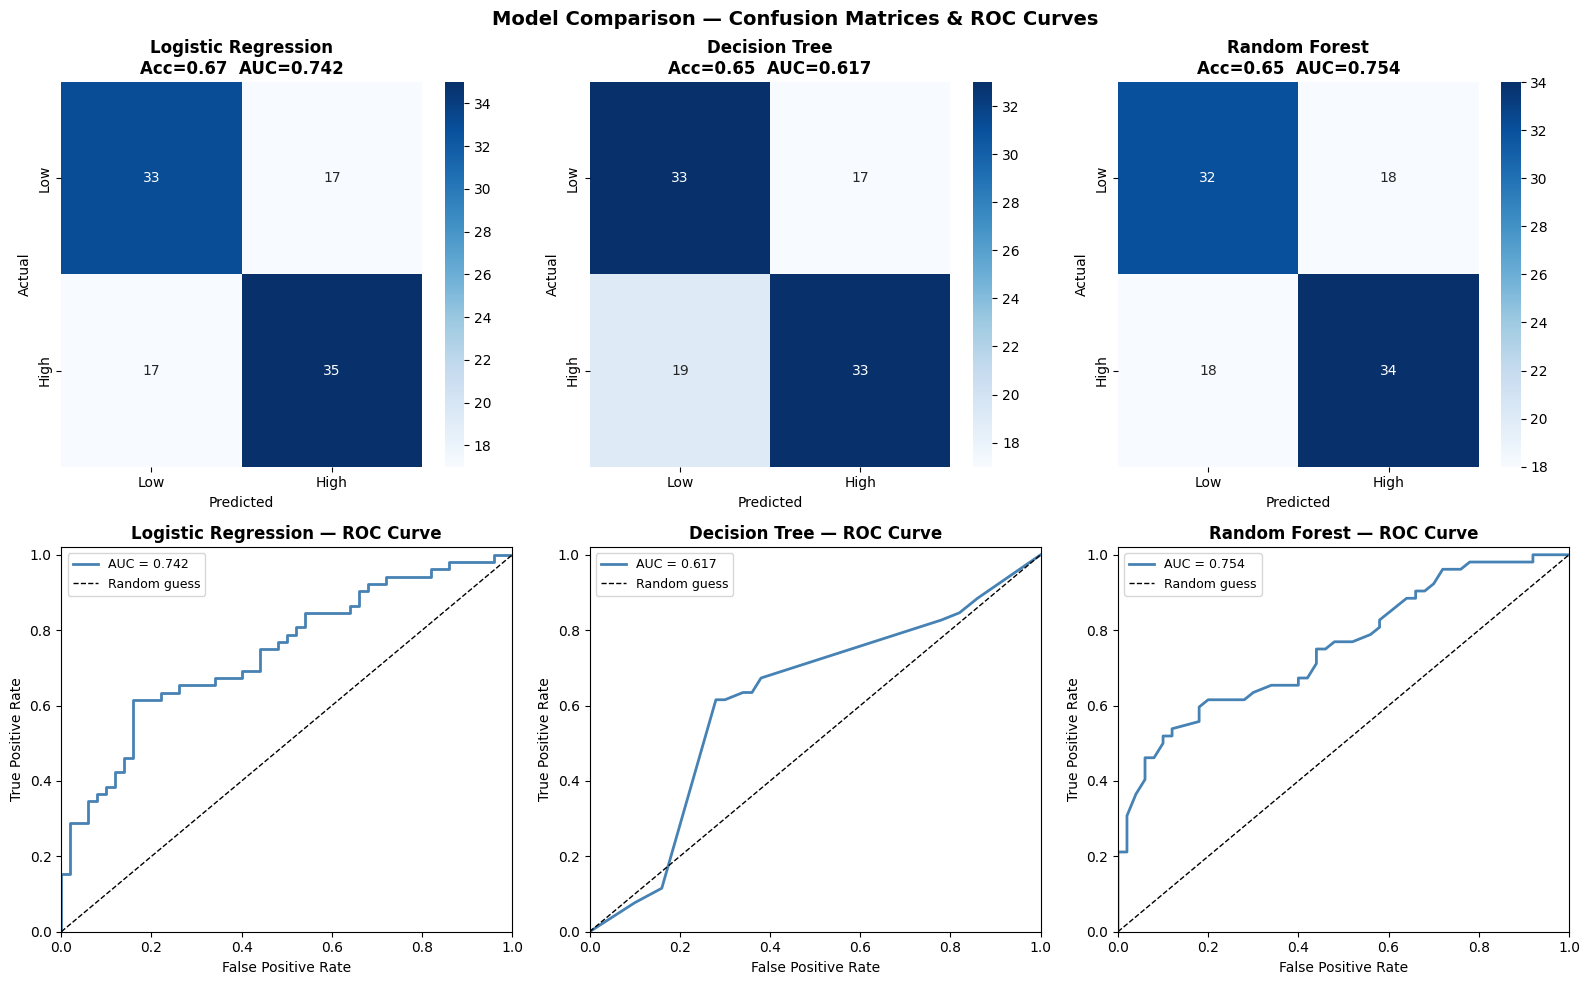


Metric               Log. Regression      Decision Tree        Random Forest
Accuracy            0.667               0.647               0.647               
F1 Low ADHD         0.66                0.647               0.64                
F1 High ADHD        0.673               0.647               0.654               
Macro F1            0.667               0.647               0.647               
AUC-ROC             0.742               0.617               0.754               


In [21]:
# ── STEP 10: Evaluate and compare ─────────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

models = {
    'Logistic Regression': (lr_model, X_test_scaled),
    'Decision Tree':       (dt_model, X_test),
    'Random Forest':       (rf_model, X_test),
}

results  = {}
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Model Comparison — Confusion Matrices & ROC Curves',
             fontsize=14, fontweight='bold')

for idx, (name, (model, X_te)) in enumerate(models.items()):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    report = classification_report(y_test, y_pred,
                                   target_names=['Low ADHD', 'High ADHD'],
                                   output_dict=True)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy':       round(report['accuracy'], 3),
        'F1 Low ADHD':    round(report['Low ADHD']['f1-score'], 3),
        'F1 High ADHD':   round(report['High ADHD']['f1-score'], 3),
        'Macro F1':       round(report['macro avg']['f1-score'], 3),
        'AUC-ROC':        round(auc, 3),
    }

    # Confusion matrix (top row)
    ax_cm = axes[0, idx]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Low', 'High'],
                yticklabels=['Low', 'High'])
    ax_cm.set_title(f'{name}\nAcc={report["accuracy"]:.2f}  AUC={auc:.3f}',
                    fontweight='bold')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_xlabel('Predicted')

    # ROC curve (bottom row)
    ax_roc = axes[1, idx]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, color='steelblue', linewidth=2,
                label=f'AUC = {auc:.3f}')
    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess')
    ax_roc.set_title(f'{name} — ROC Curve', fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(fontsize=9)
    ax_roc.set_xlim([0, 1])
    ax_roc.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print comparison table ────────────────────────────────────────────
print("\n" + "="*65)
print(f"{'Metric':<20} {'Log. Regression':<20} {'Decision Tree':<20} {'Random Forest'}")
print("="*65)
metrics = ['Accuracy', 'F1 Low ADHD', 'F1 High ADHD', 'Macro F1', 'AUC-ROC']
for metric in metrics:
    row = f"{metric:<20}"
    for name in models.keys():
        row += f"{results[name][metric]:<20}"
    print(row)
print("="*65)